# Bayesian Online Changepoint Detection (BOCPD) on S&P 500

This notebook implements the BOCPD algorithm from Adams & MacKay (2007) to detect structural breaks in S&P 500 (SPY) log returns.

**Key idea:** At each time step, the algorithm maintains a probability distribution over the *run length* — how many days have elapsed since the last changepoint. When the run length distribution suddenly shifts toward small values, a changepoint is detected.

**What BOCPD detects:** Changes in the *statistical distribution* of returns (mean or variance), not price trend direction.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from abc import ABC, abstractmethod
import scipy.stats as ss

## 1. Likelihood Model: Student-T with Normal-Gamma Conjugate Prior

The likelihood model assumes returns follow a **Student-T distribution**, which has heavier tails than a Normal — appropriate for financial returns with occasional extreme events.

The conjugate prior is a **Normal-Gamma**, parameterized by `(mu, kappa, alpha, beta)`:
- `mu`, `kappa`: prior mean and precision of the mean
- `alpha`, `beta`: shape and rate of the Gamma prior on precision (inverse variance)

At each time step, `update_theta` performs a **Bayesian update** by appending new sufficient statistics. The first element of each parameter array always holds the **prior** (for run length = 0, i.e., a fresh regime start).

In [17]:
class BaseLikelihood(ABC):
    """
    This is an abstract class to serve as a template for future users to mimick
    if they want to add new models for online bayesian changepoint detection.

    Make sure to override the abstract methods to do which is desired.
    Otherwise you will get an error.

    Update theta has **kwargs to pass in the timestep iteration (t) if desired.
    To use the time step add this into your update theta function:
        timestep = kwargs['t']
    """

    @abstractmethod
    def pdf(self, data: np.array):
        raise NotImplementedError(
            "PDF is not defined. Please define in separate class to override this function."
        )

    @abstractmethod
    def update_theta(self, data: np.array, **kwargs):
        raise NotImplementedError(
            "Update theta is not defined. Please define in separate class to override this function."
        )


class StudentT(BaseLikelihood):
    def __init__(
        self, alpha: float = 0.1, beta: float = 0.1, kappa: float = 1, mu: float = 0
    ):
        """
        StudentT distribution except normal distribution is replaced with the student T distribution
        https://en.wikipedia.org/wiki/Normal-gamma_distribution

        Parameters:
            alpha - alpha in gamma distribution prior
            beta - beta in gamma distribution prior
            mu - mean from normal distribution
            kappa - variance from normal distribution
        """

        self.alpha0 = self.alpha = np.array([alpha])
        self.beta0 = self.beta = np.array([beta])
        self.kappa0 = self.kappa = np.array([kappa])
        self.mu0 = self.mu = np.array([mu])

    def pdf(self, data: np.array):
        """
        Return the pdf function of the t distribution

        Parmeters:
            data - the datapoints to be evaluated (shape: 1 x D vector)
        """
        return ss.t.pdf(
            x=data,
            df=2 * self.alpha,
            loc=self.mu,
            scale=np.sqrt(self.beta * (self.kappa + 1) / (self.alpha * self.kappa)),
        )

    def update_theta(self, data: np.array, **kwargs):
        """
        Performs a bayesian update on the prior parameters, given data
        Parmeters:
            data - the datapoints to be evaluated (shape: 1 x D vector)
        """
        muT0 = np.concatenate(
            (self.mu0, (self.kappa * self.mu + data) / (self.kappa + 1))
        )
        kappaT0 = np.concatenate((self.kappa0, self.kappa + 1.0))
        alphaT0 = np.concatenate((self.alpha0, self.alpha + 0.5))
        betaT0 = np.concatenate(
            (
                self.beta0,
                self.beta
                + (self.kappa * (data - self.mu) ** 2) / (2.0 * (self.kappa + 1.0)),
            )
        )

        self.mu = muT0
        self.kappa = kappaT0
        self.alpha = alphaT0
        self.beta = betaT0

## 2. Data: SPY Log Returns (2016–2026)

Download daily SPY prices via `yfinance` and compute **log returns**: $r_t = \log(P_t / P_{t-1})$.

Log returns are used instead of simple returns because they are approximately additive over time and more symmetric — better suited for the Student-T likelihood model.

In [18]:
import yfinance as yf

ticker = "SPY"  # S&P 500 ETF
data = yf.download(ticker, start="2016-01-01", end="2026-04-14")
prices = data["Close"].dropna()

returns = prices.pct_change().dropna()
log_returns = np.log(prices).diff().dropna()
returns = log_returns.values.reshape(-1, 1)


/var/folders/1p/zv9y2r510759692x_7kzr_v40000gn/T/ipykernel_57742/244619363.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2016-01-01", end="2026-04-14")
[*********************100%***********************]  1 of 1 completed


## 3. Visualize Log Returns

Plot the log return series to get an intuitive sense of where volatility spikes occur. Periods of large absolute returns (e.g., March 2020) are likely candidates for changepoints.

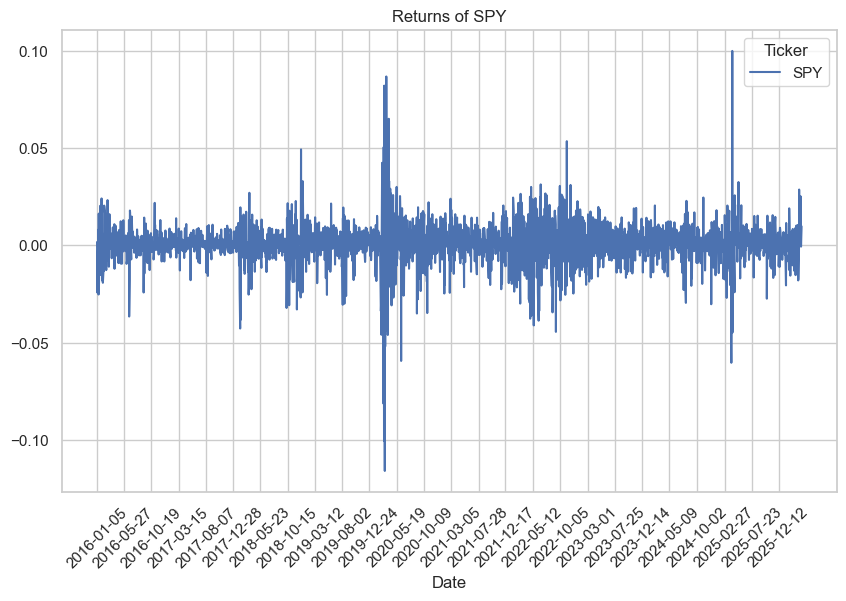

In [19]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.lineplot(data=log_returns)
plt.title('Returns of SPY')
plt.xticks(ticks=log_returns.index[::100], rotation=45)
plt.show()

In [20]:
data

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2016-01-04,169.908173,169.916620,167.854257,169.460202,222353500
2016-01-05,170.195541,170.651960,169.088292,170.229345,110845800
2016-01-06,168.048676,169.096753,167.017494,167.642956,152112600
2016-01-07,164.016937,166.882267,163.628126,165.098831,213436100
2016-01-08,162.216492,165.538251,161.929117,164.980397,209817200
...,...,...,...,...,...
2026-04-07,659.219971,659.609985,651.059998,656.650024,69980400
2026-04-08,676.010010,677.080017,671.460022,676.390015,93606100


## 4. BOCPD Algorithm

Implements Algorithm 1 from Adams & MacKay (2007).

**`growth_changepoint_prob[r, t]`** = posterior probability that the run length at time `t` is exactly `r` (i.e., the last changepoint occurred `r` steps ago).

At each step `t`, two hypotheses are evaluated:
- **Growth** (`r → r+1`): no changepoint, run length increases by 1
- **Changepoint** (`r → 0`): changepoint occurs, run length resets to 0

The **hazard rate** `H = 1/λ` is the prior probability of a changepoint at any given step. With `λ=50`, this encodes a prior belief that changepoints occur roughly every 50 trading days (~2 months).

> **Note on normalization:** The denominator uses `np.sum(col) + eps` (adding `eps` once to the total) rather than `np.sum(col + eps)` (which would add `T × eps` and inflate the denominator by ~2.6×10⁻⁴ per step).

In [21]:
T = len(returns)

lambda_  = 50 # This value is given in the paper.

alpha0 = 1 # Inverse Gamma Parameters
beta0  = 1e-4
eps = 1e-7  # A small value to avoid division by zero

# --- Original (buggy normalization: T*eps added to denominator) ---
likelihood = StudentT(alpha=alpha0, beta=beta0, kappa=1, mu=0)
growth_changepoint_prob = np.zeros((T, T))
growth_changepoint_prob[0, 0] = 1
for t in range(0, T-1):
    predictive_probability = likelihood.pdf(returns[t])
    H = np.ones(t + 1) / lambda_
    growth_changepoint_prob[1:t + 2, t + 1] = growth_changepoint_prob[:t + 1, t] * predictive_probability * (1 - H)
    growth_changepoint_prob[0, t + 1] = np.sum(growth_changepoint_prob[:t + 1, t] * predictive_probability * H)
    growth_changepoint_prob[:, t + 1] /= np.sum(growth_changepoint_prob[:, t + 1] + eps)  # bug
    likelihood.update_theta(data=returns[t])

## 5. Changepoint Signal: P(run length < 10)

`growth_changepoint_prob[0, t]` is always ≈ H by construction (with constant hazard, H factors out of the normalization). The correct signal to monitor is the **total probability mass on short run lengths**.

`P(run length < 10) = sum of rows 0–9` captures how confident the model is that a changepoint occurred recently.

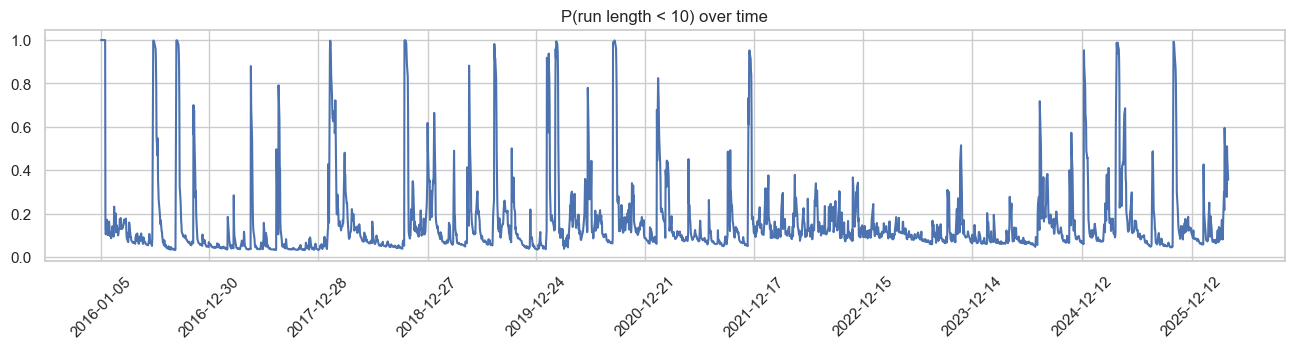

In [22]:
short_run_prob = growth_changepoint_prob[:10, :].sum(axis=0)

plt.figure(figsize=(16, 3))
plt.plot(log_returns.index, short_run_prob)
plt.title('P(run length < 10) over time')
plt.xticks(log_returns.index[::250], rotation=45)
plt.show()

## 6. Regime Segmentation and Visualization

Extract changepoints using a **probability threshold** on `P(run length < 10)` — the probability that a changepoint occurred within the last 10 days.

- A high value indicates the run length distribution has recently shifted toward small values — a changepoint signal.
- Only the **first day** of each spike is kept as the changepoint date (consecutive days above threshold belong to the same event).

The SPY price series is then colored by regime for visual inspection.

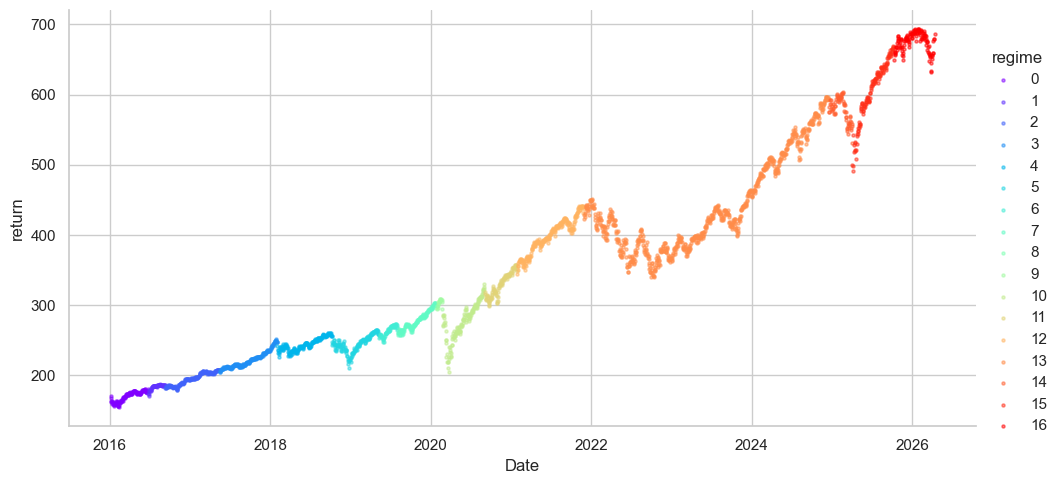

In [23]:
from matplotlib.pyplot import cm

threshold = 0.8
map_run_length = np.argmax(growth_changepoint_prob, axis=0)
changepoints = np.where(short_run_prob > threshold)[0]
changepoints = np.where(np.diff((short_run_prob > threshold).astype(int)) > 0)[0]

regime = np.zeros(T, dtype=int)
for i, cp in enumerate(changepoints):
    regime[cp:] = i + 1

close_prices = data['Close'].squeeze()
df_plot = pd.DataFrame({
    'Date': close_prices.index[1:],
    'return': close_prices.values[1:],
    'regime': regime
})

colors = cm.rainbow(np.linspace(0, 1, regime.max() + 1))
fg = sns.FacetGrid(data=df_plot, hue='regime', palette=colors, aspect=2, height=5)
fg.map(plt.scatter, 'Date', 'return', alpha=0.5, s=5).add_legend()

## 7. Detected Changepoint Dates

Dates where `P(run length < 10) > 0.8`. Each cluster corresponds to a known market event:

| Period | Event |
|--------|-------|
| Jan 2016 | China circuit-breaker crash, global sell-off |
| Jun 2016 | Brexit vote |
| Feb 2018 | "Volmageddon" — VIX spike, S&P fell 4% in one day |
| Oct 2018 | Fed rate hike fears, Q4 equity sell-off |
| Aug 2019 | US-China trade war escalation, CNY broke 7 |
| Feb–Mar 2020 | COVID-19 market crash |
| Sep 2020 | Tech sector correction |
| Dec 2021 | Omicron variant emergence |
| Dec 2024 | Fed hawkish pivot, dot plot revision |
| Apr 2025 | Trump tariff announcements |

In [24]:
threshold = 0.8
spike_dates = log_returns.index[short_run_prob > threshold]
print(spike_dates)

DatetimeIndex(['2016-01-05', '2016-01-06', '2016-01-07', '2016-01-08',
               '2016-01-11', '2016-01-12', '2016-01-13', '2016-01-14',
               '2016-01-15', '2016-01-19', '2016-06-27', '2016-06-28',
               '2016-06-29', '2016-06-30', '2016-07-01', '2016-07-05',
               '2016-07-06', '2016-09-12', '2016-09-13', '2016-09-14',
               '2016-09-15', '2016-09-16', '2016-09-19', '2016-09-20',
               '2016-09-21', '2017-05-18', '2018-02-05', '2018-02-06',
               '2018-02-07', '2018-02-08', '2018-02-09', '2018-10-11',
               '2018-10-12', '2018-10-15', '2018-10-16', '2018-10-17',
               '2018-10-18', '2018-10-19', '2018-10-22', '2019-05-14',
               '2019-08-06', '2019-08-07', '2019-08-08', '2019-08-09',
               '2019-08-12', '2020-01-28', '2020-01-29', '2020-02-03',
               '2020-02-04', '2020-02-05', '2020-02-26', '2020-02-27',
               '2020-02-28', '2020-03-02', '2020-03-03', '2020-03-04',
      

## 8. Run Length Posterior Heatmap

Visualizes the full `growth_changepoint_prob` matrix as a heatmap.

- **x-axis**: time (trading days)
- **y-axis**: run length (flipped so longer run lengths are at the top)
- **brightness**: `-log(probability)` — brighter = higher probability mass

In a stable regime, probability concentrates along a diagonal band (run length grows steadily). A **bright vertical stripe** near the bottom indicates a changepoint: probability mass collapses back to short run lengths.

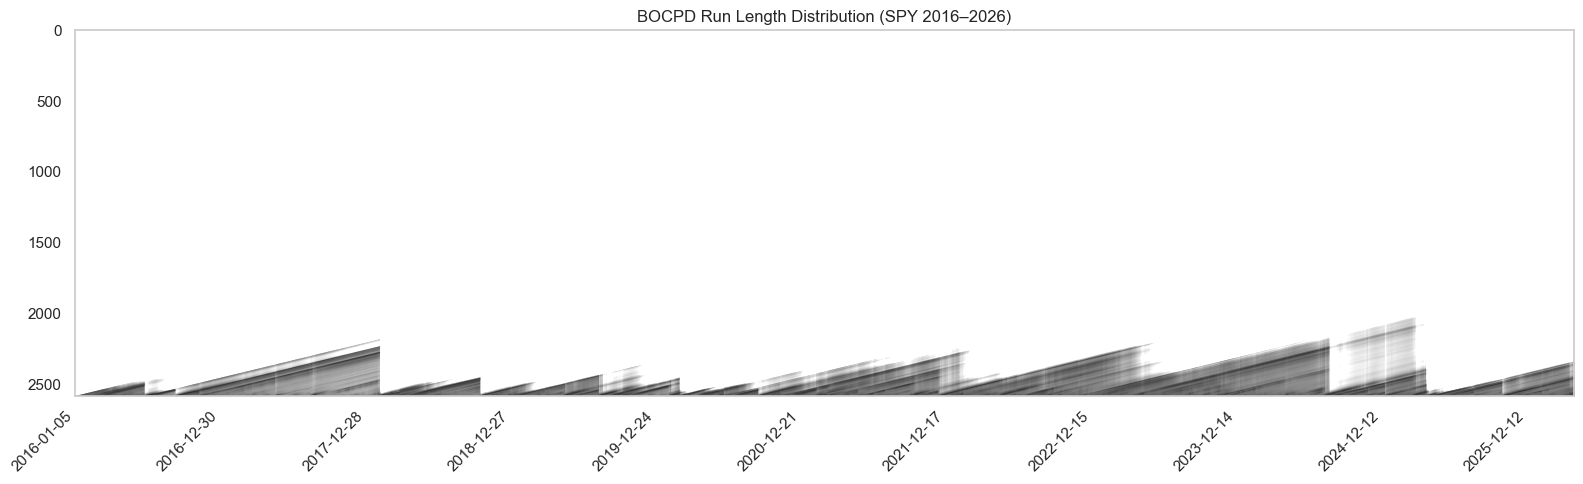

In [25]:
clims = [0, 14]
dates = pd.to_datetime(data.index)
formatted_dates = dates.strftime('%Y-%m-%d')
step = 250
tick_pos = np.arange(0, T, step)
tick_labels = list(formatted_dates[1:])[::step]

fig, ax = plt.subplots(figsize=(16, 5))
ax.imshow(-np.log(np.flipud(growth_changepoint_prob) + eps), clim=clims, aspect='auto', cmap='gray')
ax.set_title('BOCPD Run Length Distribution (SPY 2016–2026)')
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, rotation=45, ha='right')
ax.grid(False)
plt.tight_layout()
plt.show()